In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# UCI Auto MPG 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
columns = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin','car_name'
]

df = pd.read_csv(
    url,
    delim_whitespace=True,
    names=columns,
    na_values='?'
)

# clean the data
df = df.dropna()
print(df)


C:\Users\Biao Wang\AppData\Local\Temp\ipykernel_1368\187595932.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0  3504.0          12.0   
1    15.0          8         350.0       165.0  3693.0          11.5   
2    18.0          8         318.0       150.0  3436.0          11.0   
3    16.0          8         304.0       150.0  3433.0          12.0   
4    17.0          8         302.0       140.0  3449.0          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0  2790.0          15.6   
394  44.0          4          97.0        52.0  2130.0          24.6   
395  32.0          4         135.0        84.0  2295.0          11.6   
396  28.0          4         120.0        79.0  2625.0          18.6   
397  31.0          4         119.0        82.0  2720.0          19.4   

     model_year  origin                   car_name  
0            70       1  chevrolet chevelle malibu  
1            70       1      

In [72]:
print(df[['horsepower', 'displacement']].describe())

       horsepower  displacement
count  392.000000    392.000000
mean   104.469388    194.411990
std     38.491160    104.644004
min     46.000000     68.000000
25%     75.000000    105.000000
50%     93.500000    151.000000
75%    126.000000    275.750000
max    230.000000    455.000000


### Data preparation ###
We split the data set according to:
- train : validation : test = 6:2:2

In [73]:
from sklearn.model_selection import train_test_split

# Separate features and target (keep ALL feature columns)
features_temp = df.drop(columns=['mpg'])
labels = df['mpg']

# First split: training + validation vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    features_temp,
    labels,
    test_size=0.2,
    random_state=42
)

# Second split: training vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,   # 0.25 of 0.8 = 0.2
    random_state=42
)

# Verify split sizes
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)


Training set shape: (234, 8)
Validation set shape: (79, 8)
Test set shape: (79, 8)


In [74]:
print(X_train[['horsepower', 'displacement']].describe())


       horsepower  displacement
count  234.000000    234.000000
mean   104.508547    193.884615
std     38.697267    106.089967
min     48.000000     70.000000
25%     75.000000     98.000000
50%     94.500000    151.000000
75%    129.000000    302.000000
max    225.000000    455.000000


### Correlation analysis ###

In [75]:
import pandas as pd

# Combine training features and target into a single DataFrame
train_df = X_train.copy()
train_df['mpg'] = y_train

# Keep only numerical columns for correlation analysis
# (non-numeric columns such as car names cannot be used in Pearson correlation)
train_df_numeric = train_df.select_dtypes(include='number')

# Compute Pearson correlation matrix using training data only
corr_matrix = train_df_numeric.corr()

# Display the full correlation matrix
print(corr_matrix)

# Extract correlations between MPG and all numerical features
mpg_corr = corr_matrix['mpg'].drop('mpg')  # Remove self-correlation

# Rank features by the absolute value of correlation strength
mpg_corr = mpg_corr.reindex(
    mpg_corr.abs().sort_values(ascending=False).index
)

# Display feature–MPG correlations ranked by strength
print("\nCorrelation with MPG (Training Set Only):")
print(mpg_corr)


              cylinders  displacement  horsepower    weight  acceleration  \
cylinders      1.000000      0.956421    0.848290  0.898786     -0.504044   
displacement   0.956421      1.000000    0.900440  0.937842     -0.552704   
horsepower     0.848290      0.900440    1.000000  0.883385     -0.686687   
weight         0.898786      0.937842    0.883385  1.000000     -0.435045   
acceleration  -0.504044     -0.552704   -0.686687 -0.435045      1.000000   
model_year    -0.410572     -0.427497   -0.492789 -0.374405      0.328586   
origin        -0.564908     -0.608446   -0.467528 -0.582472      0.236640   
mpg           -0.783048     -0.816445   -0.801302 -0.842506      0.436971   

              model_year    origin       mpg  
cylinders      -0.410572 -0.564908 -0.783048  
displacement   -0.427497 -0.608446 -0.816445  
horsepower     -0.492789 -0.467528 -0.801302  
weight         -0.374405 -0.582472 -0.842506  
acceleration    0.328586  0.236640  0.436971  
model_year      1.000000

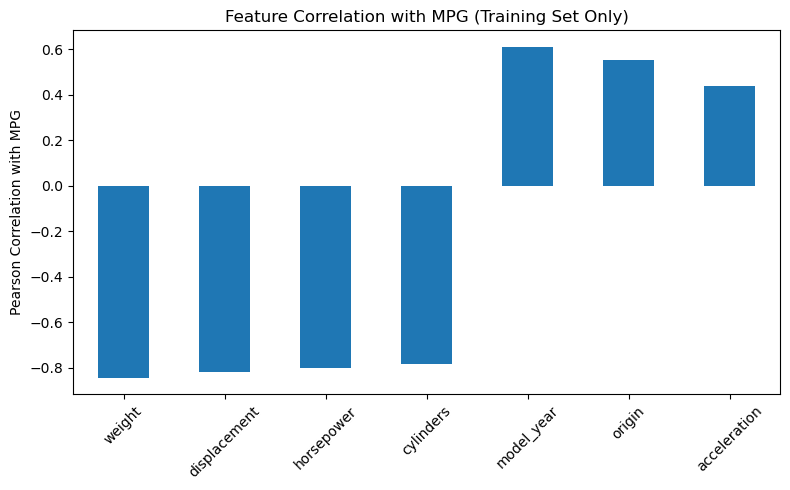

In [76]:
import matplotlib.pyplot as plt

# Combine training features and target into a single DataFrame
train_df = X_train.copy()
train_df['mpg'] = y_train

# Keep only numerical columns for correlation analysis
train_df_numeric = train_df.select_dtypes(include='number')

# Compute Pearson correlation matrix using training data only
corr_matrix = train_df_numeric.corr()

# Extract correlations between MPG and all numerical features
mpg_corr = corr_matrix['mpg'].drop('mpg')

# Sort features by absolute correlation strength
mpg_corr_sorted = mpg_corr.reindex(
    mpg_corr.abs().sort_values(ascending=False).index
)

# Plot correlation bar chart
plt.figure(figsize=(8, 5))
mpg_corr_sorted.plot(kind='bar')
plt.ylabel("Pearson Correlation with MPG")
plt.title("Feature Correlation with MPG (Training Set Only)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


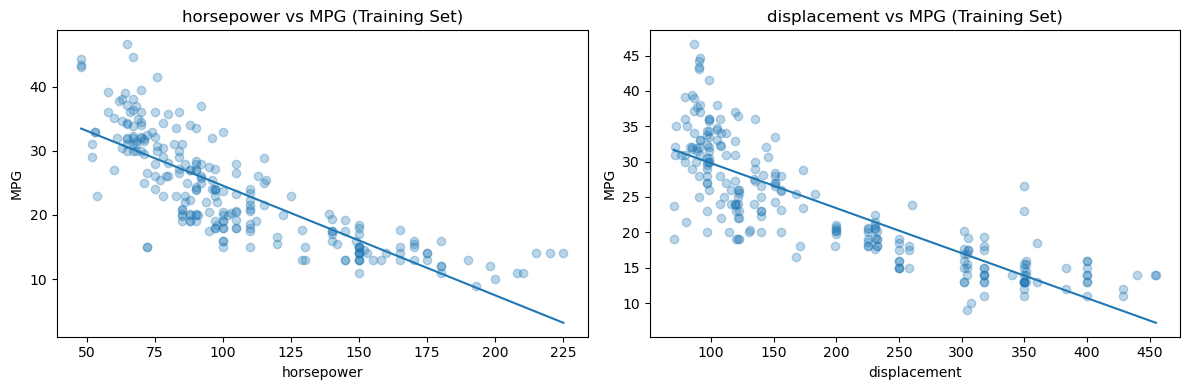

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Selected features after correlation analysis
selected_features = ['horsepower', 'displacement']
# I didn't choose cylinder since the cylinder value is not continuous

plt.figure(figsize=(12, 4))

for i, feature in enumerate(selected_features):
    plt.subplot(1, 2, i + 1)

    # Scatter plot using training data only
    plt.scatter(X_train[feature], y_train, alpha=0.3)

    # Fit and plot a linear trend line (for visualization only)
    z = np.polyfit(X_train[feature], y_train, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(X_train[feature])
    plt.plot(x_sorted, p(x_sorted))

    plt.xlabel(feature)
    plt.ylabel("MPG")
    plt.title(f"{feature} vs MPG (Training Set)")

plt.tight_layout()
plt.show()


In [78]:
# Make some functions:
def trapezoidal_membership_function(domain, a, b, c, d):
    y = np.zeros_like(domain, dtype=float)
    
    # rising edge
    idx = (a < domain) & (domain < b)
    y[idx] = (domain[idx] - a) / (b - a)

    # top
    idx = (b <= domain) & (domain <= c)
    y[idx] = 1.0

    # falling edge
    idx = (c < domain) & (domain < d)
    y[idx] = (d - domain[idx]) / (d - c)

    return y


def gauss_membership_func(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def interp_membership(domain, mf_values, x):
    """
    Equivalent to skfuzzy.interp_membership
    domain: e.g. np.linspace(...)
    mf_values: membership values on that domain
    x: crisp input
    """
    return np.interp(x, domain, mf_values)

def centroid_defuzzification(domain, aggregated_mf):
    """
    Compute centroid defuzzification (discrete version).

    domain: np.ndarray
        The universe of discourse (e.g., domain_difficulty)
    aggregated_mf: np.ndarray
        Aggregated membership values over the domain

    returns: float
        Crisp output (centroid)
    """
    numerator = np.sum(domain * aggregated_mf)
    denominator = np.sum(aggregated_mf)

    if denominator == 0:
        # no rule fired → fallback (should rarely happen)
        return np.mean(domain)

    return numerator / denominator



### We start to set the membership functions for the 2 features ###

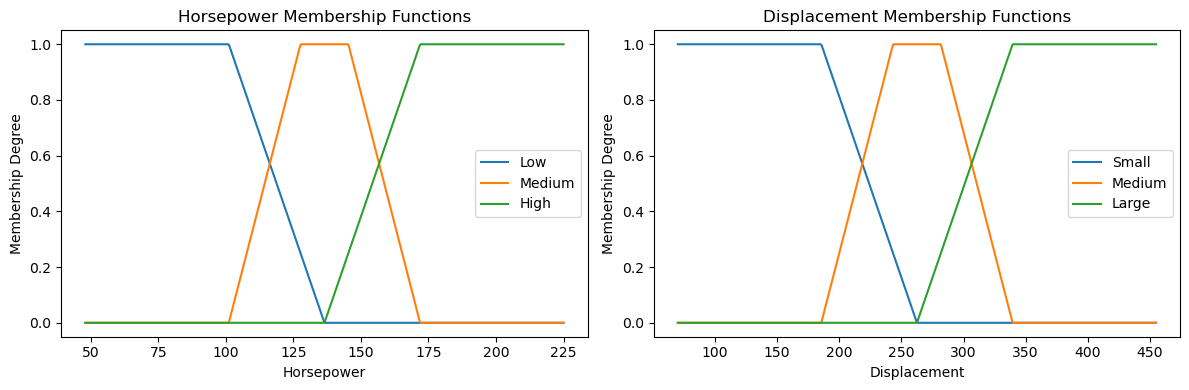

In [79]:
import numpy as np

# Define domains using training data only
hp_min, hp_max = X_train['horsepower'].min(), X_train['horsepower'].max()
disp_min, disp_max = X_train['displacement'].min(), X_train['displacement'].max()

domain_horsepower = np.linspace(hp_min, hp_max, 500)
domain_displacement = np.linspace(disp_min, disp_max, 500)

# Horsepower membership functions
hp_low = trapezoidal_membership_function(
    domain_horsepower,
    a=hp_min,
    b=hp_min,
    c=hp_min + 0.3 * (hp_max - hp_min),
    d=hp_min + 0.5 * (hp_max - hp_min)
)

hp_medium = trapezoidal_membership_function(
    domain_horsepower,
    a=hp_min + 0.3 * (hp_max - hp_min),
    b=hp_min + 0.45 * (hp_max - hp_min),
    c=hp_min + 0.55 * (hp_max - hp_min),
    d=hp_min + 0.7 * (hp_max - hp_min)
)

hp_high = trapezoidal_membership_function(
    domain_horsepower,
    a=hp_min + 0.5 * (hp_max - hp_min),
    b=hp_min + 0.7 * (hp_max - hp_min),
    c=hp_max,
    d=hp_max
)

# Displacement membership functions
disp_small = trapezoidal_membership_function(
    domain_displacement,
    a=disp_min,
    b=disp_min,
    c=disp_min + 0.3 * (disp_max - disp_min),
    d=disp_min + 0.5 * (disp_max - disp_min)
)

disp_medium = trapezoidal_membership_function(
    domain_displacement,
    a=disp_min + 0.3 * (disp_max - disp_min),
    b=disp_min + 0.45 * (disp_max - disp_min),
    c=disp_min + 0.55 * (disp_max - disp_min),
    d=disp_min + 0.7 * (disp_max - disp_min)
)

disp_large = trapezoidal_membership_function(
    domain_displacement,
    a=disp_min + 0.5 * (disp_max - disp_min),
    b=disp_min + 0.7 * (disp_max - disp_min),
    c=disp_max,
    d=disp_max
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Horsepower MFs
plt.subplot(1, 2, 1)
plt.plot(domain_horsepower, hp_low, label='Low')
plt.plot(domain_horsepower, hp_medium, label='Medium')
plt.plot(domain_horsepower, hp_high, label='High')
plt.title("Horsepower Membership Functions")
plt.xlabel("Horsepower")
plt.ylabel("Membership Degree")
plt.legend()

# Displacement MFs
plt.subplot(1, 2, 2)
plt.plot(domain_displacement, disp_small, label='Small')
plt.plot(domain_displacement, disp_medium, label='Medium')
plt.plot(domain_displacement, disp_large, label='Large')
plt.title("Displacement Membership Functions")
plt.xlabel("Displacement")
plt.ylabel("Membership Degree")
plt.legend()

plt.tight_layout()
plt.show()





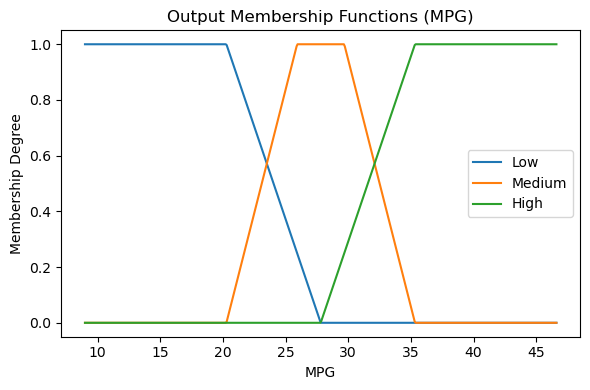

In [80]:
import numpy as np

# Define the output domain (MPG) using training targets only
mpg_min, mpg_max = y_train.min(), y_train.max()
domain_mpg = np.linspace(mpg_min, mpg_max, 500)

# Output (MPG) membership functions: Low / Medium / High
mpg_low = trapezoidal_membership_function(
    domain_mpg,
    a=mpg_min,
    b=mpg_min,
    c=mpg_min + 0.30 * (mpg_max - mpg_min),
    d=mpg_min + 0.50 * (mpg_max - mpg_min)
)

mpg_medium = trapezoidal_membership_function(
    domain_mpg,
    a=mpg_min + 0.30 * (mpg_max - mpg_min),
    b=mpg_min + 0.45 * (mpg_max - mpg_min),
    c=mpg_min + 0.55 * (mpg_max - mpg_min),
    d=mpg_min + 0.70 * (mpg_max - mpg_min)
)

mpg_high = trapezoidal_membership_function(
    domain_mpg,
    a=mpg_min + 0.50 * (mpg_max - mpg_min),
    b=mpg_min + 0.70 * (mpg_max - mpg_min),
    c=mpg_max,
    d=mpg_max
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Plot output membership functions
plt.plot(domain_mpg, mpg_low, label='Low')
plt.plot(domain_mpg, mpg_medium, label='Medium')
plt.plot(domain_mpg, mpg_high, label='High')

plt.title("Output Membership Functions (MPG)")
plt.xlabel("MPG")
plt.ylabel("Membership Degree")
plt.legend()
plt.tight_layout()
plt.show()
